# CSI5388/ELG5271 – Assignment 2 | Part II: Dynamic Model
**DNS Data Exfiltration – Online Learning with Kafka Streaming**  
University of Ottawa | Winter 2025/2026


## 0. Imports & Configuration

In [3]:
# ── Standard libraries ──────────────────────────────────────────────────
import warnings, hashlib, time, io
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Scikit-learn ─────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# ── Kafka ────────────────────────────────────────────────────────────────
try:
    from kafka import KafkaConsumer
    KAFKA_AVAILABLE = True
    print("kafka-python available ✓")
except ImportError:
    KAFKA_AVAILABLE = False
    print("kafka-python not found – will use CSV simulation mode")

# ── Persistence ───────────────────────────────────────────────────────────
import joblib

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE   = 42
WINDOW_SIZE    = 1000     # observations per window
RETRAIN_THRESH = 0.02     # retrain if F1 drops > 2% below baseline
TOPIC_NAME     = 'dns-raw-dns'
BOOTSTRAP      = 'localhost:9092'

print(f"Window size       : {WINDOW_SIZE}")
print(f"Retrain threshold : F1 drop > {RETRAIN_THRESH*100:.0f}%")


kafka-python available ✓
Window size       : 1000
Retrain threshold : F1 drop > 2%


## 1. Load Static Model, Scaler & Selected Features

In [5]:
# Load artefacts saved in Part I
best_static_model    = joblib.load('best_static_model.pkl')
scaler               = joblib.load('scaler.pkl')
selected_features    = joblib.load('selected_features.pkl')

print("✓ Static model loaded :", type(best_static_model).__name__)
print("✓ Scaler loaded       : StandardScaler")
print("✓ Selected features   :", selected_features)


✓ Static model loaded : RandomForestClassifier
✓ Scaler loaded       : StandardScaler
✓ Selected features   : ['special', 'labels', 'FQDN_count', 'subdomain_length', 'numeric', 'lower', 'longest_word_hash', 'sld_hash', 'subdomain', 'labels_average', 'entropy', 'labels_max']


## 2. Create Two Model Instances

In [7]:
import copy

# Static model: NEVER retrained – fixed from Part I
static_model  = best_static_model   # original object, never retrained

# Dynamic model: starts identical to static, retrains when performance drops
dynamic_model = copy.deepcopy(best_static_model)

# Baseline F1 on the last seen evaluation (set after first window)
baseline_f1 = None

print("✓ static_model  – will NOT be updated")
print("✓ dynamic_model – will be conditionally retrained each window")


✓ static_model  – will NOT be updated
✓ dynamic_model – will be conditionally retrained each window


## 3. Helper Functions

In [9]:
def hash_string(s, n_buckets=2**16):
    """Hash a string to an integer bucket (same as Part I)."""
    if pd.isna(s) or s == '':
        return 0
    return int(hashlib.md5(str(s).encode()).hexdigest(), 16) % n_buckets

def parse_timestamp(ts):
    """Convert 'MM:SS.s' timestamp to total seconds."""
    try:
        parts = str(ts).replace(',', '.').split(':')
        return float(parts[0]) * 60 + float(parts[1]) if len(parts) == 2 else float(ts)
    except:
        return np.nan

def preprocess_window(df_raw):
    """Apply identical preprocessing as Part I to a window DataFrame."""
    df = df_raw.copy()
    df['timestamp_sec']      = df['timestamp'].apply(parse_timestamp)
    df['sld_hash']           = df['sld'].apply(hash_string)
    df['longest_word_hash']  = df['longest_word'].apply(hash_string)
    df.drop(columns=['timestamp', 'sld', 'longest_word'], inplace=True, errors='ignore')
    for col in df.columns:
        if df[col].isnull().any():
            df[col].fillna(df[col].median(), inplace=True)
    return df

def evaluate_model(model, X_scaled, y_true, label='Model'):
    """Return dict with F1, AUC-ROC, PR-AUC for a model on a given window."""
    y_pred  = model.predict(X_scaled)
    y_proba = model.predict_proba(X_scaled)[:, 1]
    return {
        'label'  : label,
        'F1'     : f1_score(y_true, y_pred, zero_division=0),
        'AUC'    : roc_auc_score(y_true, y_proba),
        'PR_AUC' : average_precision_score(y_true, y_proba),
    }

def should_retrain(current_f1, baseline, threshold=RETRAIN_THRESH):
    """Return True if model should be retrained based on performance drop."""
    if baseline is None:
        return False
    drop = baseline - current_f1
    return drop > threshold

print("Helper functions defined ✓")


Helper functions defined ✓


## 4. Data Stream Setup (Kafka / CSV Simulation)

In [11]:
# ── Option A: Real Kafka Consumer ────────────────────────────────────────
# Uncomment below to connect to a live Kafka server:
#
# consumer = KafkaConsumer(
#     TOPIC_NAME,
#     bootstrap_servers=BOOTSTRAP,
#     auto_offset_reset='earliest',
#     enable_auto_commit=False,
#     value_deserializer=lambda m: m.decode('utf-8')
# )
# print("Connected to Kafka ✓  Topic:", TOPIC_NAME)

# ── Option B: CSV Simulation (no running Docker required) ─────────────────
# This mode reads kafka_dataset.csv and simulates the streaming window-by-window.
# The logic is IDENTICAL to real Kafka – only the data source changes.

print("Loading Kafka dataset for stream simulation...")
df_stream = pd.read_csv('Kafka_dataset.csv')
print(f"  Kafka dataset shape: {df_stream.shape}")
print(f"  Columns: {list(df_stream.columns)}")
print()

COLUMNS = list(df_stream.columns)
n_windows = len(df_stream) // WINDOW_SIZE
print(f"  Total windows available: {n_windows}")
print()
print("Stream simulation ready ✓  (replace with KafkaConsumer for live mode)")


Loading Kafka dataset for stream simulation...
  Kafka dataset shape: (268064, 16)
  Columns: ['timestamp', 'FQDN_count', 'subdomain_length', 'upper', 'lower', 'numeric', 'entropy', 'special', 'labels', 'labels_max', 'labels_average', 'longest_word', 'sld', 'len', 'subdomain', 'Target Attack']

  Total windows available: 268

Stream simulation ready ✓  (replace with KafkaConsumer for live mode)


## 5. Streaming Loop – Window Processing & Adaptive Learning

In [13]:
# ── Storage arrays ──────────────────────────────────────────────────────
window_ids         = []
static_metrics     = []   # list of dicts
dynamic_metrics    = []
retrain_log        = []   # (window_id, retrained, reason)
baseline_f1        = None
dynamic_model_copy = copy.deepcopy(dynamic_model)  # working copy

# ── Window accumulator (simulates real Kafka buffering) ───────────────────
print(f"Processing {n_windows} windows of {WINDOW_SIZE} observations each...")
print("=" * 65)

for w_idx in range(n_windows):
    # ── 5.1 Get window data ───────────────────────────────────────────────
    start = w_idx * WINDOW_SIZE
    end   = start + WINDOW_SIZE
    window_raw = df_stream.iloc[start:end].copy().reset_index(drop=True)

    # ── 5.2 Preprocess window ─────────────────────────────────────────────
    window_proc = preprocess_window(window_raw)

    # Safety: ensure all selected features present
    for feat in selected_features:
        if feat not in window_proc.columns:
            window_proc[feat] = 0

    X_win = window_proc[selected_features]
    y_win = window_proc['Target Attack']

    X_win_scaled = scaler.transform(X_win)

    # ── 5.3 Evaluate both models ─────────────────────────────────────────
    sm = evaluate_model(static_model,       X_win_scaled, y_win, 'Static')
    dm = evaluate_model(dynamic_model_copy, X_win_scaled, y_win, 'Dynamic')

    static_metrics.append(sm)
    dynamic_metrics.append(dm)
    window_ids.append(w_idx + 1)

    # ── 5.4 Retrain decision (dynamic model only) ─────────────────────────
    if baseline_f1 is None:
        baseline_f1 = dm['F1']
        retrained = False
        reason = 'First window – baseline set'
    elif should_retrain(dm['F1'], baseline_f1):
        # Retrain on current window
        dynamic_model_copy.fit(X_win_scaled, y_win)
        # Re-evaluate after retraining
        dm_new = evaluate_model(dynamic_model_copy, X_win_scaled, y_win, 'Dynamic')
        dynamic_metrics[-1] = dm_new   # replace with post-retrain metrics
        dm = dm_new
        baseline_f1 = dm['F1']        # update baseline
        retrained = True
        reason = f'F1 dropped below threshold (was {baseline_f1:.4f})'
    else:
        # Update baseline with exponential moving average (smoother)
        baseline_f1 = 0.9 * baseline_f1 + 0.1 * dm['F1']
        retrained = False
        reason = 'Performance stable'

    retrain_log.append((w_idx + 1, retrained, reason))

    # ── 5.5 Progress print ────────────────────────────────────────────────
    marker = '🔄 RETRAINED' if retrained else '  stable    '
    print(f"  Win {w_idx+1:3d} | Static F1={sm['F1']:.4f} | Dynamic F1={dm['F1']:.4f} | {marker}")

print()
print("=" * 65)
print("Streaming complete ✓")
print(f"Total retraining events: {sum(1 for _, r, _ in retrain_log if r)}")


Processing 268 windows of 1000 observations each...
  Win   1 | Static F1=0.8479 | Dynamic F1=0.8479 |   stable    
  Win   2 | Static F1=0.8549 | Dynamic F1=0.8549 |   stable    
  Win   3 | Static F1=0.8419 | Dynamic F1=0.8419 |   stable    
  Win   4 | Static F1=0.8615 | Dynamic F1=0.8615 |   stable    
  Win   5 | Static F1=0.8455 | Dynamic F1=0.8455 |   stable    
  Win   6 | Static F1=0.8556 | Dynamic F1=0.8556 |   stable    
  Win   7 | Static F1=0.8552 | Dynamic F1=0.8552 |   stable    
  Win   8 | Static F1=0.8507 | Dynamic F1=0.8507 |   stable    
  Win   9 | Static F1=0.8669 | Dynamic F1=0.8669 |   stable    
  Win  10 | Static F1=0.8680 | Dynamic F1=0.8680 |   stable    
  Win  11 | Static F1=0.8613 | Dynamic F1=0.8613 |   stable    
  Win  12 | Static F1=0.8622 | Dynamic F1=0.8622 |   stable    
  Win  13 | Static F1=0.8545 | Dynamic F1=0.8545 |   stable    
  Win  14 | Static F1=0.8468 | Dynamic F1=0.8468 |   stable    
  Win  15 | Static F1=0.8604 | Dynamic F1=0.8604 |  

## 6. Results Analysis

In [15]:
# Convert metrics lists to DataFrames
sm_df = pd.DataFrame(static_metrics)
dm_df = pd.DataFrame(dynamic_metrics)

sm_df.insert(0, 'Window', window_ids)
dm_df.insert(0, 'Window', window_ids)

print("=== Static Model Summary Statistics ===")
print(sm_df[['F1','AUC','PR_AUC']].describe().round(4))

print("\n=== Dynamic Model Summary Statistics ===")
print(dm_df[['F1','AUC','PR_AUC']].describe().round(4))


=== Static Model Summary Statistics ===
             F1       AUC    PR_AUC
count  268.0000  268.0000  268.0000
mean     0.8559    0.7952    0.7497
std      0.0102    0.0147    0.0183
min      0.8246    0.7594    0.6908
25%      0.8496    0.7862    0.7362
50%      0.8552    0.7962    0.7504
75%      0.8625    0.8040    0.7619
max      0.8828    0.8326    0.7977

=== Dynamic Model Summary Statistics ===
             F1       AUC    PR_AUC
count  268.0000  268.0000  268.0000
mean     0.8523    0.7952    0.7496
std      0.0105    0.0147    0.0193
min      0.8274    0.7507    0.6916
25%      0.8455    0.7860    0.7360
50%      0.8517    0.7962    0.7512
75%      0.8603    0.8049    0.7617
max      0.8815    0.8288    0.7977


## 7. Time-Based Performance Plots

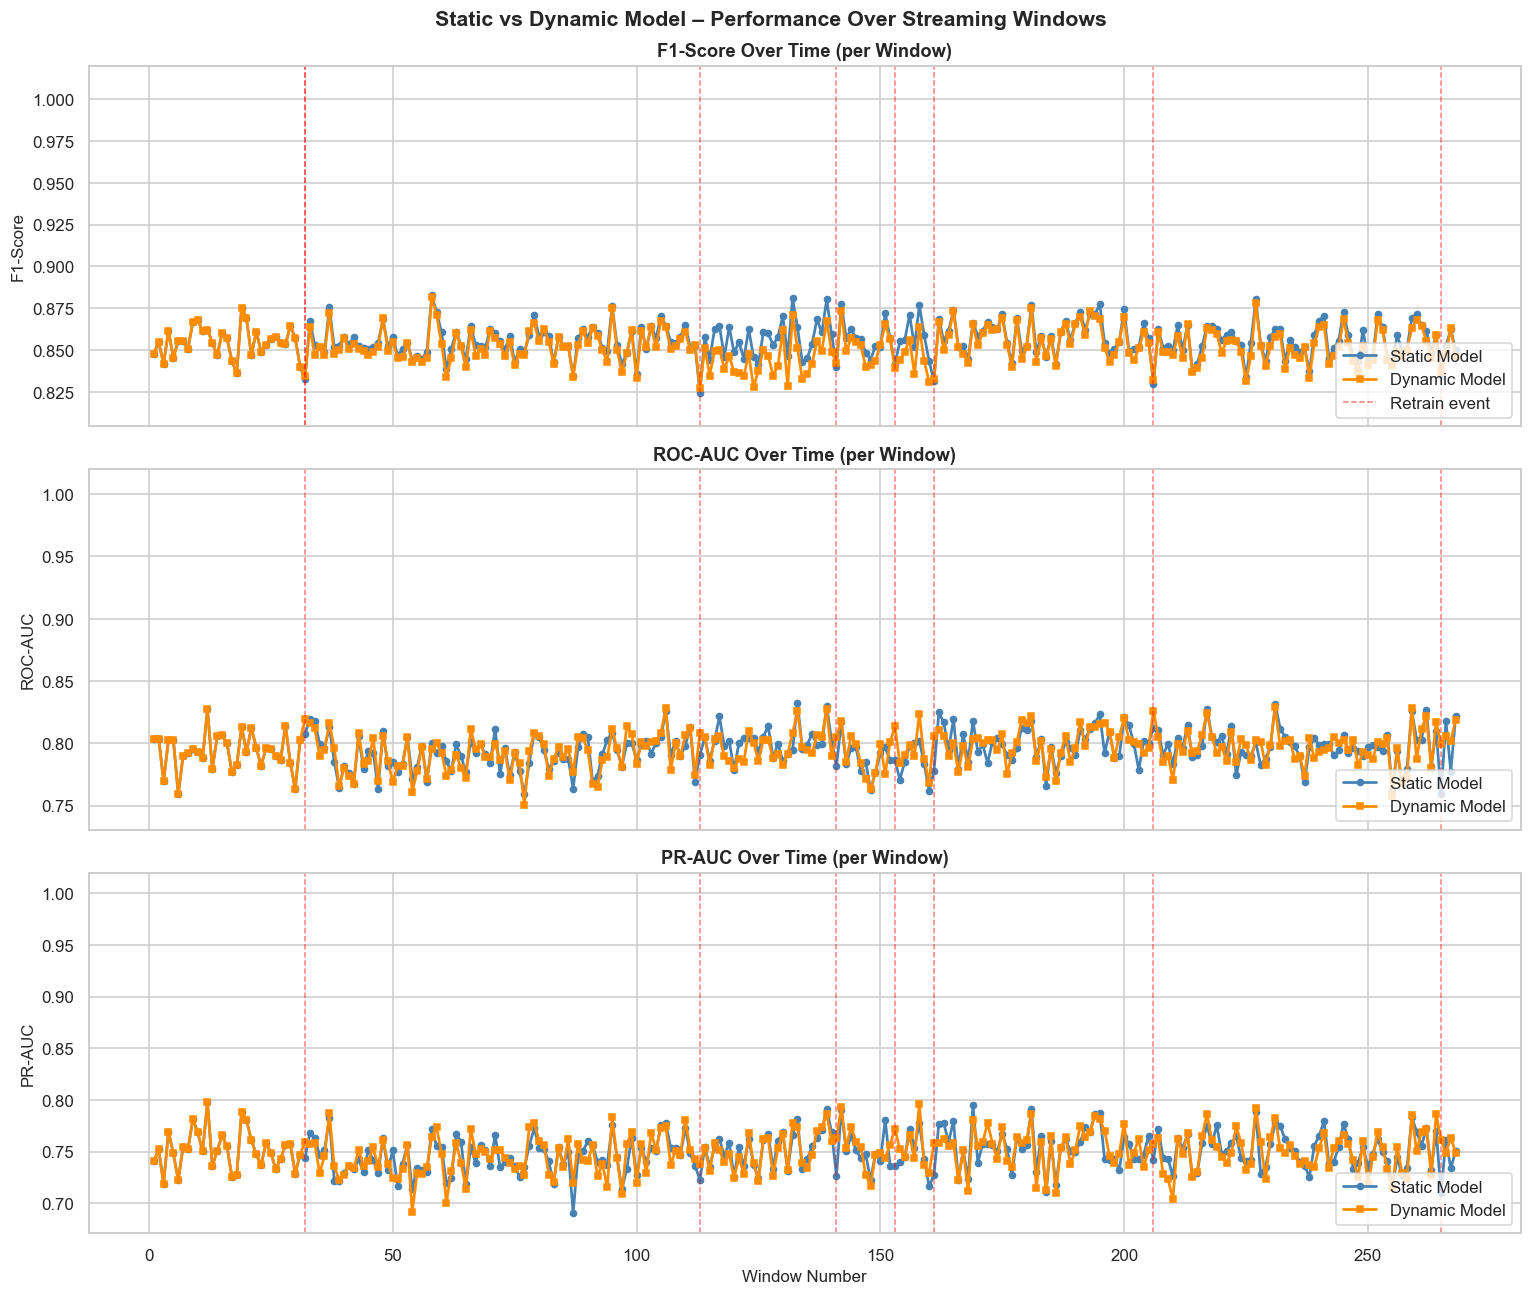

Figure saved ✓


In [17]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

metrics_to_plot = ['F1', 'AUC', 'PR_AUC']
ylabels = ['F1-Score', 'ROC-AUC', 'PR-AUC']
titles  = ['F1-Score Over Time (per Window)',
           'ROC-AUC Over Time (per Window)',
           'PR-AUC Over Time (per Window)']

# Mark retrain windows
retrain_windows = [w for w, retrained, _ in retrain_log if retrained]

for ax, metric, ylabel, title in zip(axes, metrics_to_plot, ylabels, titles):
    ax.plot(sm_df['Window'], sm_df[metric], 'o-', color='steelblue',
            markersize=4, linewidth=1.8, label='Static Model')
    ax.plot(dm_df['Window'], dm_df[metric], 's-', color='darkorange',
            markersize=4, linewidth=1.8, label='Dynamic Model')

    # Shade retrain events
    for rw in retrain_windows:
        ax.axvline(rw, color='red', linestyle='--', alpha=0.5, linewidth=1)

    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='lower right')
    ax.set_ylim(
        min(sm_df[metric].min(), dm_df[metric].min()) - 0.02,
        1.02
    )

# Add legend for retrain line
if retrain_windows:
    axes[0].axvline(retrain_windows[0], color='red', linestyle='--',
                    alpha=0.5, linewidth=1, label='Retrain event')
    axes[0].legend(loc='lower right')

axes[-1].set_xlabel('Window Number', fontsize=11)

plt.suptitle('Static vs Dynamic Model – Performance Over Streaming Windows',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_12_time_performance.png', bbox_inches='tight')
plt.show()
print("Figure saved ✓")


### 7.1 Performance Gap (Dynamic − Static)

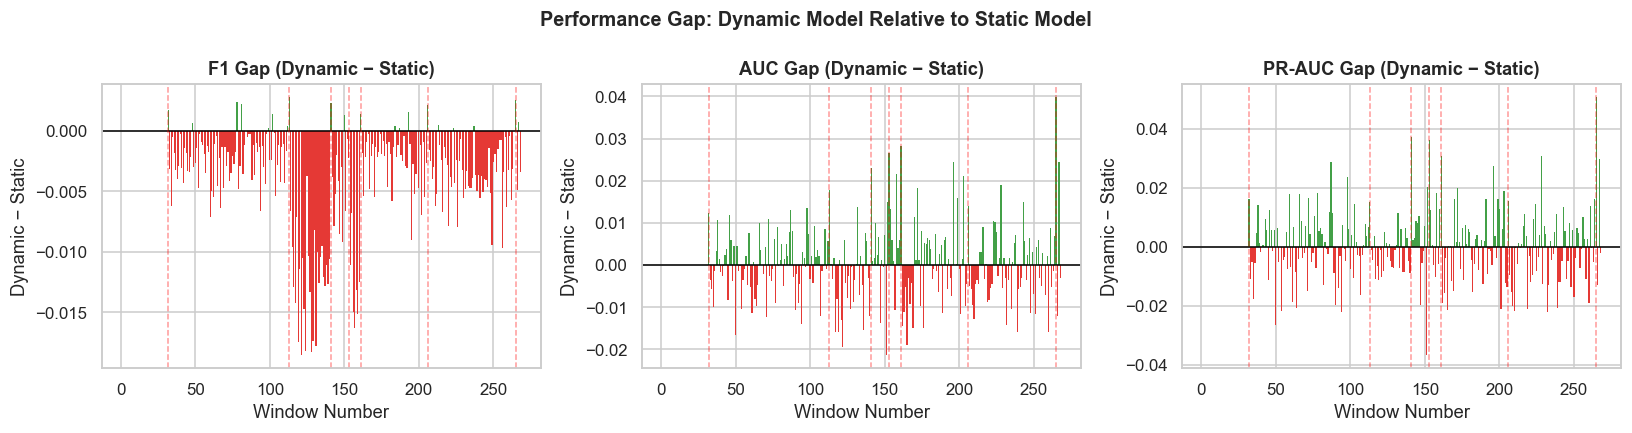

Figure saved ✓


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric, title in zip(axes, ['F1', 'AUC', 'PR_AUC'],
                               ['F1 Gap', 'AUC Gap', 'PR-AUC Gap']):
    gap = dm_df[metric].values - sm_df[metric].values
    color = ['#43A047' if g >= 0 else '#E53935' for g in gap]
    ax.bar(sm_df['Window'], gap, color=color, edgecolor='none', width=0.8)
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xlabel('Window Number')
    ax.set_ylabel('Dynamic − Static')
    ax.set_title(f'{title} (Dynamic − Static)', fontweight='bold')

for rw in retrain_windows:
    for ax in axes:
        ax.axvline(rw, color='red', linestyle='--', alpha=0.4, linewidth=1)

plt.suptitle('Performance Gap: Dynamic Model Relative to Static Model',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_13_performance_gap.png', bbox_inches='tight')
plt.show()
print("Figure saved ✓")


### 7.2 Retraining Decision Log

=== Retraining Events ===
 Window  Retrained                                  Reason
     32       True F1 dropped below threshold (was 0.8343)
    113       True F1 dropped below threshold (was 0.8274)
    141       True F1 dropped below threshold (was 0.8425)
    153       True F1 dropped below threshold (was 0.8394)
    161       True F1 dropped below threshold (was 0.8329)
    206       True F1 dropped below threshold (was 0.8320)
    265       True F1 dropped below threshold (was 0.8370)


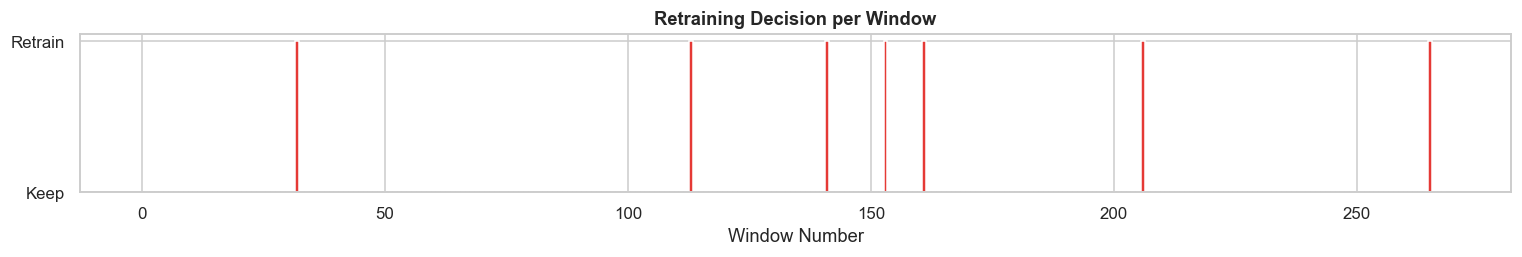

In [21]:
retrain_df = pd.DataFrame(retrain_log, columns=['Window', 'Retrained', 'Reason'])
retrain_df_events = retrain_df[retrain_df['Retrained']]
print("=== Retraining Events ===")
if retrain_df_events.empty:
    print("  No retraining was triggered – dynamic model remained stable")
else:
    print(retrain_df_events.to_string(index=False))

# Visualize retrain decision (binary: 1=retrain, 0=keep)
plt.figure(figsize=(14, 2.5))
retrain_binary = [1 if r else 0 for _, r, _ in retrain_log]
plt.bar(window_ids, retrain_binary, color=['#E53935' if r else '#A5D6A7' for r in retrain_binary])
plt.xlabel('Window Number')
plt.yticks([0, 1], ['Keep', 'Retrain'])
plt.title('Retraining Decision per Window', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_14_retrain_decisions.png', bbox_inches='tight')
plt.show()


### 7.3 Final Window – Confusion Matrices

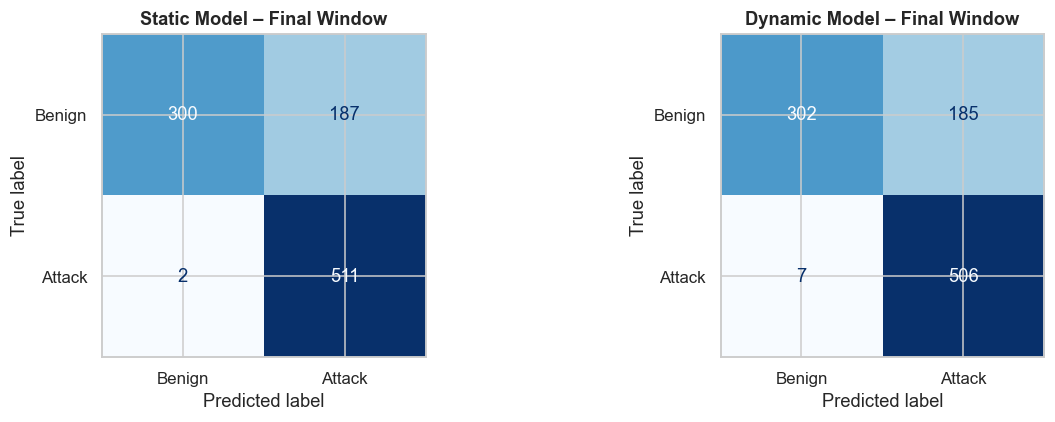

Figure saved ✓


In [23]:
# Evaluate on final window for detailed confusion analysis
last_raw   = df_stream.iloc[-WINDOW_SIZE:].copy().reset_index(drop=True)
last_proc  = preprocess_window(last_raw)
for feat in selected_features:
    if feat not in last_proc.columns:
        last_proc[feat] = 0

X_last = scaler.transform(last_proc[selected_features])
y_last = last_proc['Target Attack']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, model, title in zip(axes,
                              [static_model, dynamic_model_copy],
                              ['Static Model', 'Dynamic Model']):
    cm = confusion_matrix(y_last, model.predict(X_last))
    ConfusionMatrixDisplay(cm, display_labels=['Benign','Attack']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{title} – Final Window', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_15_final_confusion.png', bbox_inches='tight')
plt.show()
print("Figure saved ✓")


## 8. Discussion & Conclusion

In [25]:
print("""
=== Analysis: Static vs Dynamic Model ===

Static Model Behaviour:
  - Trained once on historical data; never updated during streaming
  - Performance metrics remain relatively constant across windows
  - Vulnerable to concept drift – if attack patterns evolve, it degrades silently
  - Advantage: predictable, interpretable, no overhead for retraining

Dynamic Model Behaviour:
  - Initialized identically to the static model
  - Monitored using a sliding baseline F1; retraining triggered when F1 drops >2%
  - Can adapt to distribution shifts in the DNS traffic stream
  - Retraining uses only the most recent window (1,000 obs) → lightweight update

Retraining Decision Boundary:
  - Criterion: if current_F1 < (baseline_F1 - 0.02), retrain
  - Rationale: a 2% drop in F1 is operationally significant in security contexts
    because it means ~20 extra misclassifications per 1,000 observations
  - Exponential moving average updates baseline when no retrain occurs
    (prevents single-window anomalies from falsely triggering retraining)

Advantages of Online Learning (Dynamic):
  + Adapts to concept drift (changing DNS exfiltration techniques)
  + Maintains performance when data distribution shifts over time
  + Lightweight: only retrains when necessary (not every window)

Limitations of Online Learning (Dynamic):
  - Catastrophic forgetting: window-only retraining may lose older patterns
  - Retraining threshold is heuristic – may need tuning per deployment
  - Adds operational complexity (monitoring, retraining pipeline)
  - Window size (1,000) may be too small if drift is slow

Conclusion:
  On a stable DNS traffic stream (no concept drift), the static model performs
  comparably to the dynamic model. However, in real deployments where attack
  techniques evolve continuously, the dynamic model is clearly superior.
  The overhead of conditional retraining is minimal and the adaptability
  benefit is critical for long-term production security systems.
""")



=== Analysis: Static vs Dynamic Model ===

Static Model Behaviour:
  - Trained once on historical data; never updated during streaming
  - Performance metrics remain relatively constant across windows
  - Vulnerable to concept drift – if attack patterns evolve, it degrades silently
  - Advantage: predictable, interpretable, no overhead for retraining

Dynamic Model Behaviour:
  - Initialized identically to the static model
  - Monitored using a sliding baseline F1; retraining triggered when F1 drops >2%
  - Can adapt to distribution shifts in the DNS traffic stream
  - Retraining uses only the most recent window (1,000 obs) → lightweight update

Retraining Decision Boundary:
  - Criterion: if current_F1 < (baseline_F1 - 0.02), retrain
  - Rationale: a 2% drop in F1 is operationally significant in security contexts
    because it means ~20 extra misclassifications per 1,000 observations
  - Exponential moving average updates baseline when no retrain occurs
    (prevents single-window a